# Pobranie danych i podział na train valid i test

In [1]:
import os
import random
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
# --- 1. Globalne ziarno losowości ---
SEED = 123
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# --- 2. Wczytanie i złączenie danych ---
trans = pd.read_csv("dane/train_transaction.csv")
ident = pd.read_csv("dane/train_identity.csv")

df = trans.merge(ident, on="TransactionID", how="left")

# --- 3. Podział Out-Of-Time (chronologiczny) ---
df = df.sort_values("TransactionDT").reset_index(drop=True)

n = len(df)
n_train = int(n * 0.60)
n_valid = int(n * 0.80)   # 60% + 20%

train = df.iloc[:n_train]
valid = df.iloc[n_train:n_valid]
test  = df.iloc[n_valid:]

# --- 4. Weryfikacja podziału ---
for name, part in [("train", train), ("valid", valid), ("test", test)]:
    print(f"{name:5s} | shape: {part.shape} | fraud rate: {part['isFraud'].mean():.4f}")


train | shape: (354324, 434) | fraud rate: 0.0338
valid | shape: (118108, 434) | fraud rate: 0.0390
test  | shape: (118108, 434) | fraud rate: 0.0344


# Preprocessing danych typowo pod sieci neuronowe bazując na EDA przeprowadzonym wcześniej

In [2]:
# Wymaga sklearn >= 1.3 (TargetEncoder) i scipy
import joblib
from scipy.stats import skew
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (MinMaxScaler, OneHotEncoder,
                                    TargetEncoder, FunctionTransformer)
from sklearn.impute import SimpleImputer

# ── Stałe i grupy kolumn ─────────────────────────────────────────────────────
TARGET         = 'isFraud'
MISSING_THRESH = 0.80   # dla nie-V: odrzuć kolumny z NaN > 80%
V_CORR_THRESH  = 0.05   # dla V_xxx: zachowaj jeśli |corr(isFraud)| ≥ 0.05
VAR_THRESH     = 0.01   # odrzuć cechy numeryczne z wariancją < 0.01
SKEW_THRESH    = 3      # signed_log1p tylko dla |skewness| > 3
CARD_THRESH    = 15     # granica cat_low / cat_high

# Wykrywamy grupy kolumn ze struktury surowych danych
M_COLS  = [c for c in train.columns if c.startswith('M') and c[1:].isdigit()]
D_COLS  = [c for c in train.columns if c.startswith('D') and c[1:].isdigit()]
ID_COLS = [c for c in train.columns
           if c.startswith('id_') or c in ('DeviceType', 'DeviceInfo')]

# ── 1. Feature Engineering ───────────────────────────────────────────────────
def engineer_features(df):
    df = df.copy()

    # Czas z TransactionDT
    df['hour']      = (df['TransactionDT'] // 3600) % 24
    df['dayofweek'] = (df['TransactionDT'] // (3600 * 24)) % 7

    # Flaga: email nadawcy == email odbiorcy (fraud rate 3x wyższy gdy True wg EDA)
    df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(np.int64)

    # M1–M9: T→1, F→0, NaN→-1
    # NaN to odrębny stan semantyczny (niezweryfikowane), nie brakująca wartość
    for c in M_COLS:
        if c in df.columns:
            df[c] = df[c].map({'T': 1, 'F': 0}).fillna(-1).astype(np.float64)

    # Flagi missingness dla bloków D i identity:
    # sam brak wartości koreluje z fraudem (np. D7: 14.9% vs 2.7% wg EDA)
    for c in D_COLS + ID_COLS:
        if c in df.columns:
            df[f'{c}_isnan'] = df[c].isna().astype(np.int64)

    return df.drop(columns=['TransactionID', 'TransactionDT', TARGET], errors='ignore')

X_train = engineer_features(train);  y_train = train[TARGET].reset_index(drop=True)
X_valid = engineer_features(valid);  y_valid = valid[TARGET].reset_index(drop=True)
X_test  = engineer_features(test);   y_test  = test[TARGET].reset_index(drop=True)

# ── 2. Filtracja kolumn ──────────────────────────────────────────────────────
isnan_cols   = [c for c in X_train.columns if c.endswith('_isnan')]
v_cols       = [c for c in X_train.columns if c.startswith('V') and c[1:].isdigit()]
missing_rate = X_train.isna().mean()

# V_xxx: zachowaj jeśli NaN < 80% LUB |korelacja z isFraud| ≥ 0.05
# Ślepa filtracja 80% odrzucałaby 23 kolumny V o korelacji 0.05–0.28 (wg EDA)
v_corr = X_train[v_cols].corrwith(y_train).abs()
v_keep = [c for c in v_cols
          if missing_rate[c] < MISSING_THRESH or v_corr.get(c, 0) >= V_CORR_THRESH]

# Pozostałe (bez V_xxx i flag _isnan): standardowy próg 80%
# _isnan flagi zawsze zachowujemy – mają 0 NaN i niosą sygnał
other_cols = [c for c in X_train.columns if c not in v_cols + isnan_cols]
other_keep = [c for c in other_cols if missing_rate.get(c, 0) < MISSING_THRESH]

keep_cols = v_keep + other_keep + isnan_cols
X_train, X_valid, X_test = X_train[keep_cols], X_valid[keep_cols], X_test[keep_cols]
print(f"Kolumny po filtracji: {len(keep_cols)} "
      f"(V_xxx: {len(v_keep)}, inne: {len(other_keep)}, _isnan: {len(isnan_cols)})")

# ── 3. Grupy zmiennych, wariancja, skośność ──────────────────────────────────
# "Stable" = kolumny celowo wykluczone z VarianceThreshold i signed_log1p:
#   _isnan: binarne 0/1, semantycznie istotne nawet przy niskiej wariancji
#   M_COLS: pre-zakodowane {-1, 0, 1} – nie mają sensu logować
stable = set(isnan_cols) | {c for c in M_COLS if c in X_train.columns}

num_all = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_all = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

# Filtr wariancji (tylko nie-stable)
num_for_filter = [c for c in num_all if c not in stable]
selector = VarianceThreshold(threshold=VAR_THRESH)
selector.fit(X_train[num_for_filter])
low_var  = [c for c, ok in zip(num_for_filter, selector.get_support()) if not ok]

X_train = X_train.drop(columns=low_var)
X_valid = X_valid.drop(columns=low_var)
X_test  = X_test.drop(columns=low_var)
num_all = [c for c in num_all if c not in low_var]
print(f"Usunięto {len(low_var)} cech o niskiej wariancji → {len(num_all)} cech num")

# Skośność (tylko nie-stable) → signed_log1p kompresuje ogon bez wykrzywiania pozostałych
skewness   = X_train[[c for c in num_all if c not in stable]].apply(lambda c: skew(c.dropna()))
num_skew   = skewness[skewness.abs() > SKEW_THRESH].index.tolist()
num_normal = [c for c in num_all if c not in num_skew]  # zawiera stable

cat_low  = [c for c in cat_all if X_train[c].nunique() < CARD_THRESH]
cat_high = [c for c in cat_all if X_train[c].nunique() >= CARD_THRESH]

print(f"Numeryczne: {len(num_all)} (skośne: {len(num_skew)}, normalne+stable: {len(num_normal)})")
print(f"Kat. niska kard.: {len(cat_low)}  → {cat_low}")
print(f"Kat. wysoka kard.: {len(cat_high)} → {cat_high}")

# ── 4. ColumnTransformer ─────────────────────────────────────────────────────
def signed_log1p(x):
    # Kompresuje skośne rozkłady; działa dla x ujemnych (w odróżnieniu od log1p)
    return np.sign(x) * np.log1p(np.abs(x))

preprocessor = ColumnTransformer(transformers=[
    ('num_skew', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(signed_log1p, validate=False)),
        ('scl', MinMaxScaler()),
    ]), num_skew),
    ('num_normal', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', MinMaxScaler()),
    ]), num_normal),
    ('cat_low', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary')),
    ]), cat_low),
    ('cat_high', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('enc', TargetEncoder(target_type='binary', smooth='auto')),  # kategoria → P(fraud)
        ('scl', MinMaxScaler()),
    ]), cat_high),
], remainder='drop')

# ── 5. Fit & Transform (fit tylko na train) ──────────────────────────────────
preprocessor.fit(X_train, y_train)

X_train_proc = preprocessor.transform(X_train).astype(np.float32)
X_valid_proc  = preprocessor.transform(X_valid).astype(np.float32)
X_test_proc   = preprocessor.transform(X_test).astype(np.float32)

assert not np.isnan(X_train_proc).any(), "NaN w X_train_proc!"
assert not np.isnan(X_valid_proc).any(),  "NaN w X_valid_proc!"
assert not np.isnan(X_test_proc).any(),   "NaN w X_test_proc!"

print(f"\nGotowe macierze Numpy:")
print(f"X_train_proc : {X_train_proc.shape}")
print(f"X_valid_proc : {X_valid_proc.shape}")
print(f"X_test_proc  : {X_test_proc.shape}")
print(f"dtype        : {X_train_proc.dtype}")

# ── 7. Zapis ─────────────────────────────────────────────────────────────────
joblib.dump(preprocessor,             'preprocessor.pkl')
joblib.dump(X_train.columns.tolist(), 'input_cols.pkl')  # finalna lista kolumn wejściowych
print("\nZapisano: preprocessor.pkl, input_cols.pkl")


c:\Users\matma\Documents\SGH\SEM II\Data mining\Projekt_DM\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\matma\Documents\SGH\SEM II\Data mining\Projekt_DM\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Kolumny po filtracji: 444 (V_xxx: 321, inne: 68, _isnan: 55)
Usunięto 25 cech o niskiej wariancji → 402 cech num
Numeryczne: 402 (skośne: 247, normalne+stable: 155)
Kat. niska kard.: 13  → ['ProductCD', 'card4', 'card6', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']
Kat. wysoka kard.: 4 → ['P_emaildomain', 'R_emaildomain', 'id_31', 'DeviceInfo']

Gotowe macierze Numpy:
X_train_proc : (354324, 451)
X_valid_proc : (118108, 451)
X_test_proc  : (118108, 451)
dtype        : float32

Zapisano: preprocessor.pkl, input_cols.pkl


# Trenowanie różnie sparametryzowanych sieci

### import potrzebnych bibliotek i stworzenie folderów na wyniki eksperymentów

In [3]:
import os
import json
import time
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve,
)
import matplotlib.pyplot as plt

SEED = 123
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Tworzenie katalogów na wyniki eksperymentów
ART_DIR = Path("artifacts_mlp");  ART_DIR.mkdir(exist_ok=True)
HIST_DIR = ART_DIR / "history";   HIST_DIR.mkdir(exist_ok=True)
PLOT_DIR = ART_DIR / "plots";     PLOT_DIR.mkdir(exist_ok=True)

Device: cuda


### Definiowanie różnych funkcji straty, których użyjemy w eksperymentach

In [4]:
class FocalLoss(nn.Module):
    """Focal Loss dla klasyfikacji binarnej (logits -> [0,1] sigmoid w środku).

    L = -alpha_t * (1 - p_t)^gamma * log(p_t)
    alpha to waga klasy pozytywnej; (1-alpha) dla negatywnej.
    """
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # numerycznie stabilne BCE per-element
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        p = torch.sigmoid(logits)
        p_t = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - p_t) ** self.gamma * bce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


class DiceLoss(nn.Module):
    """Soft Dice Loss dla klasyfikacji binarnej.

    L = 1 - 2*sum(p*y) / (sum(p) + sum(y) + eps)
    Działa na probach po sigmoid; niezbalansowanie nie wpływa,
    bo licznik i mianownik skalują się tak samo.
    """
    def __init__(self, eps: float = 1.0):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        p = torch.sigmoid(logits)
        inter = (p * targets).sum()
        denom = p.sum() + targets.sum() + self.eps
        return 1.0 - (2.0 * inter + self.eps) / denom


def build_loss(loss_name: str, pos_weight: torch.Tensor | None):
    if loss_name == "BCEWithLogitsLoss+pos_weight":
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    if loss_name == "FocalLoss(alpha=0.75,gamma=2.0)":
        return FocalLoss(alpha=0.75, gamma=2.0)
    if loss_name == "DiceLoss":
        return DiceLoss()
    raise ValueError(loss_name)

### Definiowanie badanych przez nas architektur modeli na potrzeby funkcji treningowej (potem w kodzie)

In [5]:
class SimpleMLP(nn.Module):
    """451 -> 128 -> 1. Jedna warstwa ukryta."""
    def __init__(self, in_dim: int, hidden: int = 128, dropout: float = 0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


class MediumMLP(nn.Module):
    """451 -> 256 -> 128 -> 64 -> 1 (LayerNorm + Dropout=0.30). Baseline z run_id=3."""
    def __init__(self, in_dim: int, dropout: float = 0.30):
        super().__init__()
        dims = [in_dim, 256, 128, 64]
        layers = []
        for i in range(len(dims) - 1):
            layers += [
                nn.Linear(dims[i], dims[i + 1]),
                nn.LayerNorm(dims[i + 1]),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
        layers.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


class ResidualBlock(nn.Module):
    """LayerNorm + Linear + LeakyReLU + Dropout + Linear, ze skip connection.
    Jeśli wymiary się nie zgadzają – liniowa projekcja w skip."""
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.15,
                 negative_slope: float = 0.01):
        super().__init__()
        self.norm = nn.LayerNorm(in_dim)
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.act = nn.LeakyReLU(negative_slope)
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        h = self.norm(x)
        h = self.fc1(h)
        h = self.act(h)
        h = self.drop(h)
        h = self.fc2(h)
        return self.act(h + self.skip(x))


class AdvancedResMLP(nn.Module):
    """451 -> 512 -> 256 -> 128 -> 64 -> 1, z residual blockami + LeakyReLU."""
    def __init__(self, in_dim: int, dropout: float = 0.15):
        super().__init__()
        self.blocks = nn.Sequential(
            ResidualBlock(in_dim, 512, dropout),
            ResidualBlock(512, 256, dropout),
            ResidualBlock(256, 128, dropout),
            ResidualBlock(128, 64, dropout),
        )
        self.head = nn.Linear(64, 1)

    def forward(self, x):
        return self.head(self.blocks(x)).squeeze(-1)


# Domyślny dropout per architektura – odwzorowuje wartości używane w grid searchu.
# build_model(..., dropout=None) => użyj tych wartości (zachowuje stare wyniki).
DEFAULT_DROPOUT = {"simple": 0.15, "medium": 0.15, "advanced": 0.15}


def build_model(arch: str, in_dim: int, dropout: float | None = None) -> nn.Module:
    # dropout=None -> domyślny dla danej architektury (jak w grid searchu).
    # Podaj wartość jawnie, gdy chcesz ją nadpisać (np. tuning runów 10-12),
    # zamiast edytować definicję modelu.
    d = DEFAULT_DROPOUT[arch] if dropout is None else dropout
    if arch == "simple":
        return SimpleMLP(in_dim, dropout=d)
    if arch == "medium":
        return MediumMLP(in_dim, dropout=d)
    if arch == "advanced":
        return AdvancedResMLP(in_dim, dropout=d)
    raise ValueError(arch)

### Definicje Early Stopping oraz funkcji do ewaluacji modeli

In [6]:
class EarlyStopping:
    """Maksymalizacja metryki na valid (PR-AUC lub F1). Przechowuje best_state_dict."""
    def __init__(self, patience: int = 10, mode: str = "max"):
        self.patience = patience
        self.mode = mode
        self.best = -np.inf if mode == "max" else np.inf
        self.counter = 0
        self.best_state = None
        self.best_epoch = -1

    def step(self, score: float, model: nn.Module, epoch: int) -> bool:
        improved = (self.mode == "max" and score > self.best) or \
                   (self.mode == "min" and score < self.best)
        if improved:
            self.best = score
            self.best_state = deepcopy(model.state_dict())
            self.best_epoch = epoch
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


@torch.no_grad()
def predict_proba(model: nn.Module, X: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    model.eval()
    out = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i + batch_size]).to(DEVICE)
        out.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(out)


def best_f1_threshold(y_true: np.ndarray, y_proba: np.ndarray) -> tuple[float, float]:
    """Próg maksymalizujący F1 (przez precision_recall_curve – tańsze niż grid)."""
    p, r, t = precision_recall_curve(y_true, y_proba)
    # f1 dla każdego punktu (ostatni punkt nie ma odpowiadającego thresholdu)
    f1 = 2 * p * r / (p + r + 1e-12)
    f1 = f1[:-1]  # przycinamy do długości t
    if len(f1) == 0:
        return 0.5, 0.0
    idx = int(np.argmax(f1))
    return float(t[idx]), float(f1[idx])


def evaluate(y_true: np.ndarray, y_proba: np.ndarray, threshold: float) -> dict:
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "ROC_AUC":   roc_auc_score(y_true, y_proba),
        "AUPRC":     average_precision_score(y_true, y_proba),
    }

### Zdefiniowanie pętli treningowej

In [7]:
def train_one(
    model: nn.Module,
    X_train: np.ndarray, y_train: np.ndarray,
    X_valid: np.ndarray, y_valid: np.ndarray,
    loss_fn: nn.Module,
    *,
    max_epochs: int = 80,
    batch_size: int = 2048,
    lr: float = 1e-3,
    weight_decay: float = 1e-5,
    patience: int = 10,
    es_metric: str = "AUPRC",   # "AUPRC" lub "F1"
    verbose: bool = True,
) -> tuple[dict, dict]:
    """Zwraca (history, best_info). best_info ma best_state_dict, best_epoch, best_score."""
    ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.float32)))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=False)

    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=5, min_lr=1e-6
    )
    es = EarlyStopping(patience=patience, mode="max")

    history = {
        "epoch": [], "train_loss": [], "val_loss": [],
        "val_F1": [], "val_Precision": [], "val_Recall": [],
        "val_ROC_AUC": [], "val_AUPRC": [], "val_threshold": [],
    }

    for epoch in range(1, max_epochs + 1):
        # ---- trening ----
        model.train()
        tot_loss, n_seen = 0.0, 0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            tot_loss += loss.item() * xb.size(0); n_seen += xb.size(0)
        train_loss = tot_loss / n_seen

        # ---- walidacja ----
        with torch.no_grad():
            model.eval()
            val_logits = []
            for i in range(0, len(X_valid), batch_size):
                xb = torch.from_numpy(X_valid[i:i + batch_size]).to(DEVICE)
                val_logits.append(model(xb))
            val_logits = torch.cat(val_logits)  # GPU
            val_targets = torch.from_numpy(y_valid.astype(np.float32)).to(DEVICE)
            val_loss = float(loss_fn(val_logits, val_targets).item())
            val_proba = torch.sigmoid(val_logits).cpu().numpy()

        scheduler.step(val_loss)

        thr, _ = best_f1_threshold(y_valid, val_proba)
        m = evaluate(y_valid, val_proba, thr)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_F1"].append(m["F1"])
        history["val_Precision"].append(m["Precision"])
        history["val_Recall"].append(m["Recall"])
        history["val_ROC_AUC"].append(m["ROC_AUC"])
        history["val_AUPRC"].append(m["AUPRC"])
        history["val_threshold"].append(thr)

        cur_lr = opt.param_groups[0]["lr"]
        score = m[es_metric]
        stop = es.step(score, model, epoch)
        if verbose:
            print(f"  ep{epoch:03d} | tr_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"F1={m['F1']:.4f} AUPRC={m['AUPRC']:.4f} ROC_AUC={m['ROC_AUC']:.4f} "
                  f"thr={thr:.3f} lr={cur_lr:.2e} | best_{es_metric}={es.best:.4f} (ep{es.best_epoch})")
        if stop:
            if verbose:
                print(f"  ⏹ early stop @ ep{epoch} (no improv {patience} epochs)")
            break

    # przywróć najlepsze wagi
    if es.best_state is not None:
        model.load_state_dict(es.best_state)
    return history, {"best_epoch": es.best_epoch, "best_score": es.best, "es_metric": es_metric}


### Zdefiniowanie funkcji do stworzenia wykresu z przebiegu treningu

In [8]:
def plot_history(history: dict, title: str, save_path: Path | None = None,
                 best_epoch: int | None = None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ep = history["epoch"]

    # wygładzone val_loss (rolling mean, okno=5) – czytelniejsze przy pos_weight
    val_loss_raw = np.array(history["val_loss"])
    kernel = min(5, len(val_loss_raw))
    val_loss_smooth = np.convolve(val_loss_raw, np.ones(kernel) / kernel, mode="same")

    axes[0].plot(ep, history["train_loss"], label="train_loss")
    axes[0].plot(ep, val_loss_raw,          alpha=0.25, color="tab:orange", label="_nolegend_")
    axes[0].plot(ep, val_loss_smooth,       color="tab:orange", label="val_loss (smooth)")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, history["val_AUPRC"],   label="AUPRC (ES metric)")
    axes[1].plot(ep, history["val_ROC_AUC"], label="ROC_AUC")
    axes[1].plot(ep, history["val_F1"],      label="F1", linestyle="--", alpha=0.7)
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("score")
    axes[1].set_title("Valid metrics"); axes[1].legend(); axes[1].grid(alpha=0.3)

    if best_epoch is not None:
        for ax in axes:
            ax.axvline(best_epoch, color="red", linestyle=":", linewidth=1.5,
                       label=f"best ep={best_epoch}")
        axes[0].legend(); axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()

### Główna funkcja do treningu i grid searchu parametrów

In [9]:
RESULTS_XLSX = Path("experiment_results_mlp.xlsx")
RESULTS_COLS = [
    "run_id", "model", "bottleneck", "dropout", "loss_fn",
    "epochs_trained", "val_loss", "scoring_method", "threshold_strategy",
    "F1", "Precision", "Recall", "ROC_AUC", "AUPRC",
    "threshold", "notes",
]


def append_results(row: dict):
    if RESULTS_XLSX.exists():
        df = pd.read_excel(RESULTS_XLSX)
    else:
        df = pd.DataFrame(columns=RESULTS_COLS)
    df = pd.concat([df, pd.DataFrame([row], columns=RESULTS_COLS)], ignore_index=True)
    df.to_excel(RESULTS_XLSX, index=False)


def next_run_id() -> int:
    if not RESULTS_XLSX.exists():
        return 1
    df = pd.read_excel(RESULTS_XLSX)
    return int(df["run_id"].max()) + 1 if len(df) else 1


def run_grid_search(
    X_train_proc, y_train, X_valid_proc, y_valid, X_test_proc, y_test,
    architectures=("simple", "medium", "advanced"),
    losses=("BCEWithLogitsLoss+pos_weight",
            "FocalLoss(alpha=0.75,gamma=2.0)",
            "DiceLoss"),
    max_epochs: int = 100,
    patience: int = 10,
    es_metric: str = "AUPRC",
    pos_weight_cap: float | None = 10.0,
    lr: float = 1e-3,
    batch_size: int = 2048,
    dropout: float | None = None,   # NOWE: None = domyślny per arch (stare wyniki); wartość = nadpisanie
    tag_suffix: str = "",           # NOWE: dopisek do nazw plików, by tuning nie nadpisał wag grid searchu
):
    """Iteruje po (arch × loss). Zapisuje best wagi, historię JSON i wiersz w xlsx."""
    # konwersje
    Xtr = X_train_proc.astype(np.float32)
    Xva = X_valid_proc.astype(np.float32)
    Xte = X_test_proc.astype(np.float32)
    ytr = np.asarray(y_train).astype(np.float32)
    yva = np.asarray(y_valid).astype(np.float32)
    yte = np.asarray(y_test).astype(np.float32)

    in_dim = Xtr.shape[1]

    # pos_weight – proporcja neg/pos w treningu (z opcjonalnym capem)
    pos = float((ytr == 1).sum()); neg = float((ytr == 0).sum())
    pw = neg / max(pos, 1.0)
    pw_used = pw if pos_weight_cap is None else min(pw, pos_weight_cap)
    pos_weight_tensor = torch.tensor([pw_used], dtype=torch.float32, device=DEVICE)
    print(f"pos_weight raw={pw:.2f}, used={pw_used:.2f} "
          f"(cap={pos_weight_cap}); train_pos_rate={pos/(pos+neg):.4f}")

    summary_rows = []

    for arch in architectures:
        for loss_name in losses:
            tag = f"{arch}_{loss_name}".replace(" ", "").replace("/", "")
            tag_safe = (tag
                        .replace("+", "_")
                        .replace("(", "_").replace(")", "")
                        .replace("=", "").replace(",", "_").replace(".", ""))
            tag_safe = tag_safe + tag_suffix   # NOWE: dopisek chroni przed nadpisaniem wag
            # NOWE: faktycznie użyty dropout (do build_model i do zapisu w xlsx)
            dropout_used = DEFAULT_DROPOUT[arch] if dropout is None else dropout
            print(f"\n========== {arch.upper()} | {loss_name} "
                  f"| dropout={dropout_used} ==========")
            torch.manual_seed(SEED); np.random.seed(SEED)

            model = build_model(arch, in_dim, dropout=dropout)   # NOWE: przekazujemy dropout
            loss_fn = build_loss(loss_name, pos_weight_tensor)

            t0 = time.time()
            history, best = train_one(
                model, Xtr, ytr, Xva, yva, loss_fn,
                max_epochs=max_epochs, patience=patience,
                es_metric=es_metric, verbose=True,
                lr=lr, batch_size=batch_size,
            )
            elapsed = time.time() - t0

            # zapis wag
            weights_path = ART_DIR / f"best_mlp_{tag_safe}.pth"
            torch.save(model.state_dict(), weights_path)

            # zapis historii
            hist_path = HIST_DIR / f"history_{tag_safe}.json"
            with open(hist_path, "w") as f:
                json.dump(history, f, indent=2)

            # wykres
            plot_history(history, title=f"{arch} | {loss_name}",
                         save_path=PLOT_DIR / f"loss_{tag_safe}.png",
                         best_epoch=best["best_epoch"])

            # ewaluacja: progi z valid → test
            val_proba = predict_proba(model, Xva)
            thr, _ = best_f1_threshold(yva, val_proba)
            val_m = evaluate(yva, val_proba, thr)

            test_proba = predict_proba(model, Xte)
            test_m = evaluate(yte, test_proba, thr)

            # idx najlepszej epoki w history (do val_loss)
            best_ep_idx = history["epoch"].index(best["best_epoch"])
            val_loss_at_best = history["val_loss"][best_ep_idx]
            epochs_trained = len(history["epoch"])

            notes = (
                f"arch={arch} | loss={loss_name} | "
                f"pos_w_used={pw_used:.2f} | lr={lr} wd=1e-5 bs={batch_size} "
                f"patience={patience} ES={es_metric} | "
                f"best_ep={best['best_epoch']} time={elapsed:.0f}s | "
                f"test_F1={test_m['F1']:.4f} test_AUC={test_m['ROC_AUC']:.4f} "
                f"test_Gini={2*test_m['ROC_AUC']-1:.4f} test_AUPRC={test_m['AUPRC']:.4f}"
            )

            row = {
                "run_id":            next_run_id(),
                "model":             f"FraudMLP_{arch}",
                "bottleneck":        "-",
                "dropout":           round(dropout_used, 4),   # NOWE: faktyczny dropout (nie zahardcodowane 0.30)
                "loss_fn":           loss_name,
                "epochs_trained":    epochs_trained,
                "val_loss":          round(val_loss_at_best, 6),
                "scoring_method":    "sigmoid_prob",
                "threshold_strategy": "max_F1_on_valid",
                "F1":                round(val_m["F1"], 4),
                "Precision":         round(val_m["Precision"], 4),
                "Recall":            round(val_m["Recall"], 4),
                "ROC_AUC":           round(val_m["ROC_AUC"], 4),
                "AUPRC":             round(val_m["AUPRC"], 4),
                "threshold":         round(thr, 4),
                "notes":             notes,
            }
            append_results(row)
            summary_rows.append({**row,
                                 "test_F1": test_m["F1"],
                                 "test_AUC": test_m["ROC_AUC"],
                                 "test_AUPRC": test_m["AUPRC"]})

            print(f"  ✓ weights → {weights_path.name}")
            print(f"  ✓ history → {hist_path.name}")
            print(f"  VAL  : {val_m}")
            print(f"  TEST : {test_m} (thr={thr:.4f})")

    return pd.DataFrame(summary_rows)

### Wywołanie kodu

pos_weight raw=28.56, used=10.00 (cap=10.0); train_pos_rate=0.0338

========== SIMPLE | BCEWithLogitsLoss+pos_weight | dropout=0.15 ==========
  ep001 | tr_loss=0.5605 val_loss=0.5350 F1=0.4355 AUPRC=0.4333 ROC_AUC=0.8637 thr=0.613 lr=1.00e-03 | best_AUPRC=0.4333 (ep1)
  ep002 | tr_loss=0.4887 val_loss=0.5205 F1=0.4597 AUPRC=0.4630 ROC_AUC=0.8707 thr=0.720 lr=1.00e-03 | best_AUPRC=0.4630 (ep2)
  ep003 | tr_loss=0.4699 val_loss=0.5172 F1=0.4760 AUPRC=0.4820 ROC_AUC=0.8765 thr=0.561 lr=1.00e-03 | best_AUPRC=0.4820 (ep3)
  ep004 | tr_loss=0.4522 val_loss=0.5057 F1=0.4846 AUPRC=0.4958 ROC_AUC=0.8813 thr=0.693 lr=1.00e-03 | best_AUPRC=0.4958 (ep4)
  ep005 | tr_loss=0.4426 val_loss=0.5100 F1=0.5000 AUPRC=0.5089 ROC_AUC=0.8838 thr=0.635 lr=1.00e-03 | best_AUPRC=0.5089 (ep5)
  ep006 | tr_loss=0.4333 val_loss=0.4966 F1=0.5090 AUPRC=0.5167 ROC_AUC=0.8858 thr=0.581 lr=1.00e-03 | best_AUPRC=0.5167 (ep6)
  ep007 | tr_loss=0.4306 val_loss=0.5481 F1=0.5125 AUPRC=0.5170 ROC_AUC=0.8852 thr=0.492 lr=1.0

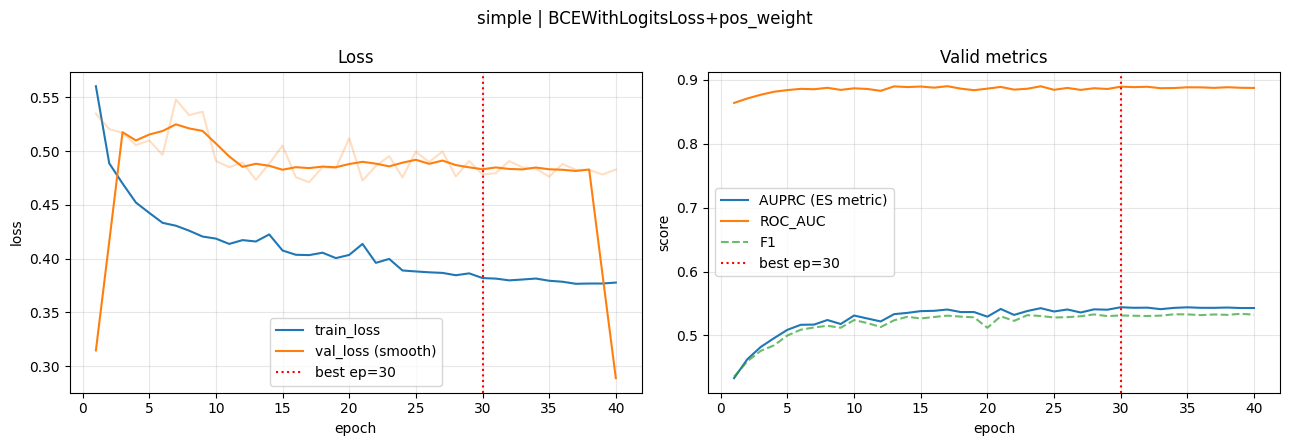

  ✓ weights → best_mlp_simple_BCEWithLogitsLoss_pos_weight.pth
  ✓ history → history_simple_BCEWithLogitsLoss_pos_weight.json
  VAL  : {'F1': 0.53125, 'Precision': 0.6076514939960905, 'Recall': 0.4719149859032748, 'ROC_AUC': 0.8891489162517109, 'AUPRC': 0.5441547520038034}
  TEST : {'F1': 0.4461559248750169, 'Precision': 0.49475576865448007, 'Recall': 0.40625, 'ROC_AUC': 0.8599858120446398, 'AUPRC': 0.397719554468316} (thr=0.7020)

========== SIMPLE | FocalLoss(alpha=0.75,gamma=2.0) | dropout=0.15 ==========
  ep001 | tr_loss=0.0179 val_loss=0.0170 F1=0.4336 AUPRC=0.4286 ROC_AUC=0.8625 thr=0.453 lr=1.00e-03 | best_AUPRC=0.4286 (ep1)
  ep002 | tr_loss=0.0154 val_loss=0.0167 F1=0.4526 AUPRC=0.4564 ROC_AUC=0.8685 thr=0.484 lr=1.00e-03 | best_AUPRC=0.4564 (ep2)
  ep003 | tr_loss=0.0148 val_loss=0.0163 F1=0.4794 AUPRC=0.4836 ROC_AUC=0.8765 thr=0.425 lr=1.00e-03 | best_AUPRC=0.4836 (ep3)
  ep004 | tr_loss=0.0142 val_loss=0.0164 F1=0.4934 AUPRC=0.5027 ROC_AUC=0.8828 thr=0.418 lr=1.00e-03 | be

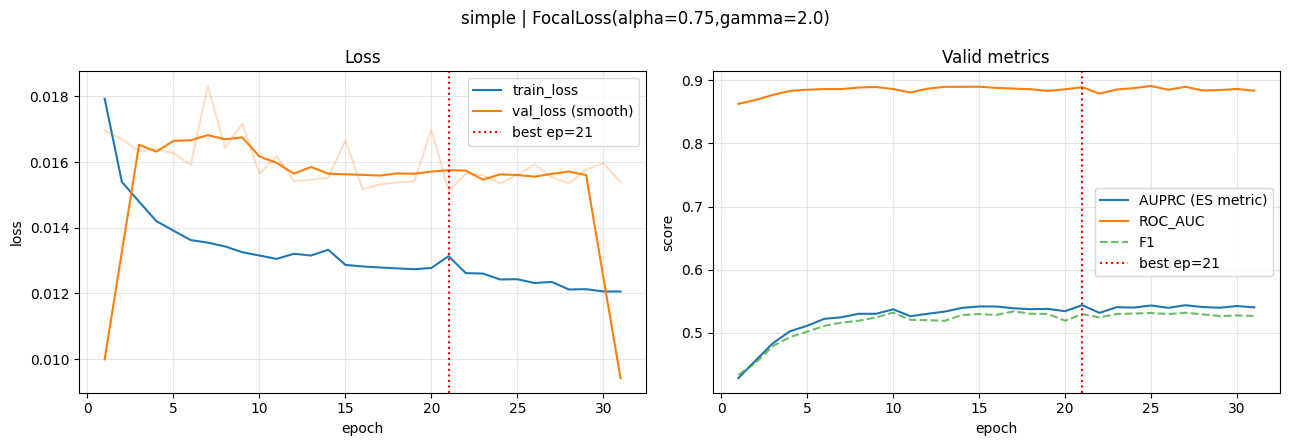

  ✓ weights → best_mlp_simple_FocalLoss_alpha075_gamma20.pth
  ✓ history → history_simple_FocalLoss_alpha075_gamma20.json
  VAL  : {'F1': 0.5298857486470234, 'Precision': 0.5947624190064795, 'Recall': 0.4777705486879202, 'ROC_AUC': 0.8887036017814581, 'AUPRC': 0.5439090737675105}
  TEST : {'F1': 0.4410405387561072, 'Precision': 0.47591906526075806, 'Recall': 0.4109251968503937, 'ROC_AUC': 0.8594500655673165, 'AUPRC': 0.394622767832573} (thr=0.4774)

========== SIMPLE | DiceLoss | dropout=0.15 ==========
  ep001 | tr_loss=0.7148 val_loss=0.6172 F1=0.4128 AUPRC=0.3537 ROC_AUC=0.6965 thr=0.691 lr=1.00e-03 | best_AUPRC=0.3537 (ep1)
  ep002 | tr_loss=0.6086 val_loss=0.5909 F1=0.4351 AUPRC=0.3778 ROC_AUC=0.7166 thr=0.076 lr=1.00e-03 | best_AUPRC=0.3778 (ep2)
  ep003 | tr_loss=0.5748 val_loss=0.5687 F1=0.4517 AUPRC=0.3962 ROC_AUC=0.7525 thr=0.108 lr=1.00e-03 | best_AUPRC=0.3962 (ep3)
  ep004 | tr_loss=0.5546 val_loss=0.5628 F1=0.4633 AUPRC=0.4125 ROC_AUC=0.7932 thr=0.104 lr=1.00e-03 | best_AU

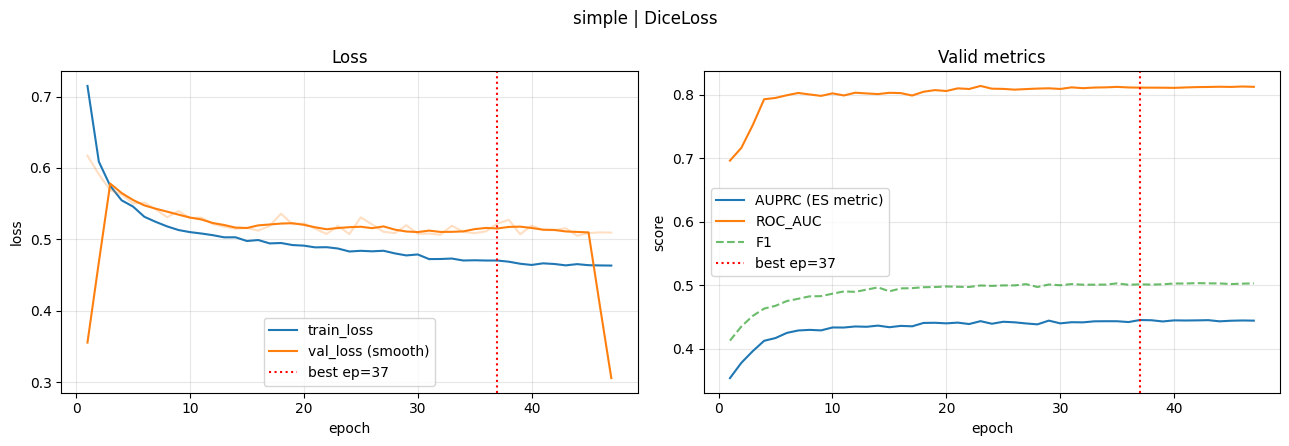

  ✓ weights → best_mlp_simple_DiceLoss.pth
  ✓ history → history_simple_DiceLoss.json
  VAL  : {'F1': 0.5015299026425591, 'Precision': 0.6991081814656843, 'Recall': 0.391021470396877, 'ROC_AUC': 0.8115569410577571, 'AUPRC': 0.4452762643542555}
  TEST : {'F1': 0.453680981595092, 'Precision': 0.6021986970684039, 'Recall': 0.36392716535433073, 'ROC_AUC': 0.7938743558398651, 'AUPRC': 0.3622779875567114} (thr=0.0160)

========== MEDIUM | BCEWithLogitsLoss+pos_weight | dropout=0.15 ==========
  ep001 | tr_loss=0.5279 val_loss=0.6134 F1=0.4280 AUPRC=0.4283 ROC_AUC=0.8466 thr=0.862 lr=1.00e-03 | best_AUPRC=0.4283 (ep1)
  ep002 | tr_loss=0.4823 val_loss=0.6942 F1=0.4919 AUPRC=0.4936 ROC_AUC=0.8731 thr=0.850 lr=1.00e-03 | best_AUPRC=0.4936 (ep2)
  ep003 | tr_loss=0.4737 val_loss=0.5155 F1=0.5063 AUPRC=0.5066 ROC_AUC=0.8799 thr=0.591 lr=1.00e-03 | best_AUPRC=0.5066 (ep3)
  ep004 | tr_loss=0.4435 val_loss=0.4898 F1=0.5176 AUPRC=0.5242 ROC_AUC=0.8863 thr=0.764 lr=1.00e-03 | best_AUPRC=0.5242 (ep4)


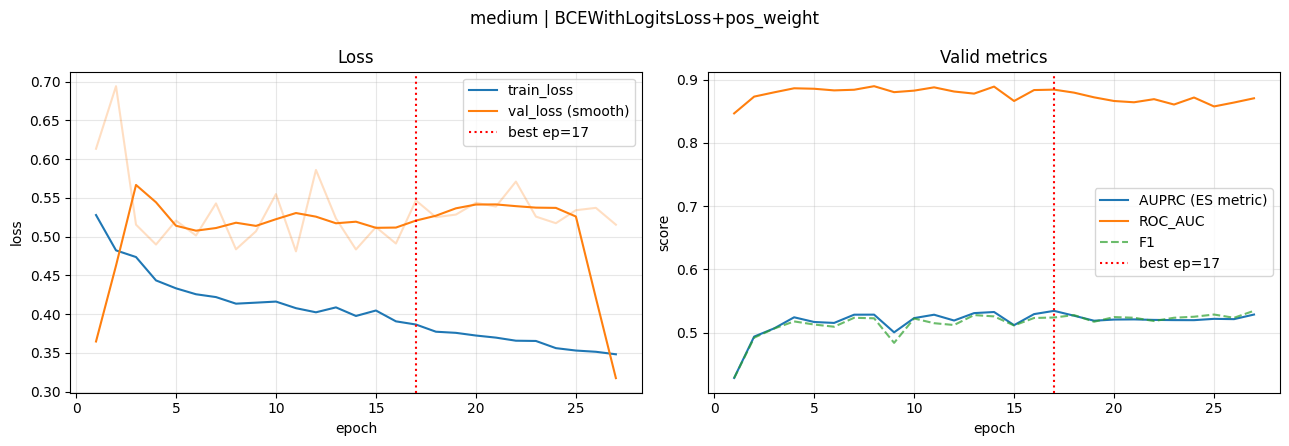

  ✓ weights → best_mlp_medium_BCEWithLogitsLoss_pos_weight.pth
  ✓ history → history_medium_BCEWithLogitsLoss_pos_weight.json
  VAL  : {'F1': 0.5238394766637313, 'Precision': 0.6237267825044938, 'Recall': 0.4515289525048796, 'ROC_AUC': 0.8841233319251904, 'AUPRC': 0.5343455440878301}
  TEST : {'F1': 0.4483338000560067, 'Precision': 0.5201429499675114, 'Recall': 0.3939468503937008, 'ROC_AUC': 0.8407000273775393, 'AUPRC': 0.41565776284013617} (thr=0.5292)

========== MEDIUM | FocalLoss(alpha=0.75,gamma=2.0) | dropout=0.15 ==========
  ep001 | tr_loss=0.0172 val_loss=0.0170 F1=0.4580 AUPRC=0.4530 ROC_AUC=0.8569 thr=0.452 lr=1.00e-03 | best_AUPRC=0.4530 (ep1)
  ep002 | tr_loss=0.0150 val_loss=0.0225 F1=0.4790 AUPRC=0.4761 ROC_AUC=0.8706 thr=0.691 lr=1.00e-03 | best_AUPRC=0.4761 (ep2)
  ep003 | tr_loss=0.0150 val_loss=0.0158 F1=0.5001 AUPRC=0.5088 ROC_AUC=0.8815 thr=0.527 lr=1.00e-03 | best_AUPRC=0.5088 (ep3)
  ep004 | tr_loss=0.0141 val_loss=0.0160 F1=0.5197 AUPRC=0.5233 ROC_AUC=0.8861 thr

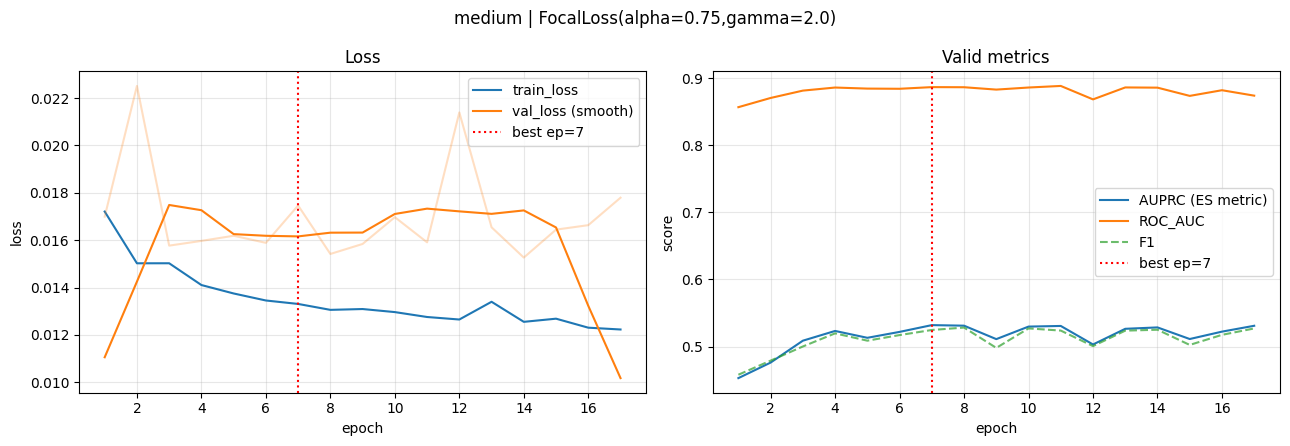

  ✓ weights → best_mlp_medium_FocalLoss_alpha075_gamma20.pth
  ✓ history → history_medium_FocalLoss_alpha075_gamma20.json
  VAL  : {'F1': 0.5247158002299144, 'Precision': 0.6382846488502175, 'Recall': 0.4454565170245066, 'ROC_AUC': 0.8867588806227507, 'AUPRC': 0.5319754277489046}
  TEST : {'F1': 0.4430203399275564, 'Precision': 0.5105973025048169, 'Recall': 0.391240157480315, 'ROC_AUC': 0.8558517427622216, 'AUPRC': 0.41956995144724807} (thr=0.3729)

========== MEDIUM | DiceLoss | dropout=0.15 ==========
  ep001 | tr_loss=0.6839 val_loss=0.5965 F1=0.4099 AUPRC=0.3433 ROC_AUC=0.7914 thr=0.262 lr=1.00e-03 | best_AUPRC=0.3433 (ep1)
  ep002 | tr_loss=0.6107 val_loss=0.6027 F1=0.4256 AUPRC=0.2437 ROC_AUC=0.7868 thr=0.999 lr=1.00e-03 | best_AUPRC=0.3433 (ep1)
  ep003 | tr_loss=0.6057 val_loss=0.7593 F1=0.3233 AUPRC=0.1844 ROC_AUC=0.7340 thr=1.000 lr=1.00e-03 | best_AUPRC=0.3433 (ep1)
  ep004 | tr_loss=0.8661 val_loss=0.8001 F1=0.4122 AUPRC=0.3622 ROC_AUC=0.8250 thr=1.000 lr=1.00e-03 | best_AU

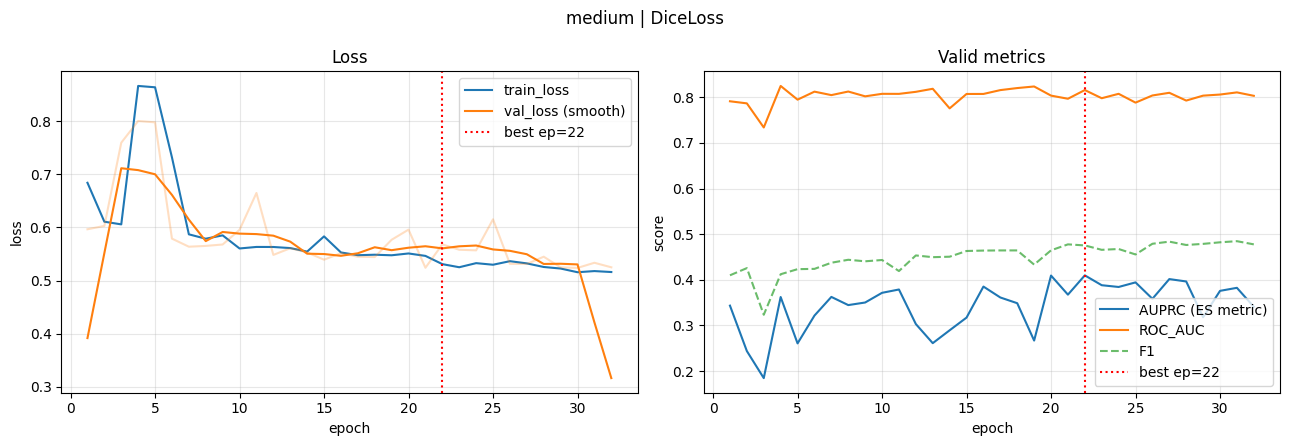

  ✓ weights → best_mlp_medium_DiceLoss.pth
  ✓ history → history_medium_DiceLoss.json
  VAL  : {'F1': 0.4753531277025079, 'Precision': 0.7086377309840997, 'Recall': 0.3576230752548254, 'ROC_AUC': 0.8159834498409027, 'AUPRC': 0.40972097289944626}
  TEST : {'F1': 0.43217665615141954, 'Precision': 0.6019332161687171, 'Recall': 0.33710629921259844, 'ROC_AUC': 0.8053330712148123, 'AUPRC': 0.3563161763797823} (thr=0.0000)

========== ADVANCED | BCEWithLogitsLoss+pos_weight | dropout=0.15 ==========
  ep001 | tr_loss=0.5269 val_loss=0.5848 F1=0.4929 AUPRC=0.4972 ROC_AUC=0.8785 thr=0.415 lr=1.00e-03 | best_AUPRC=0.4972 (ep1)
  ep002 | tr_loss=0.4540 val_loss=0.4981 F1=0.5070 AUPRC=0.5091 ROC_AUC=0.8777 thr=0.746 lr=1.00e-03 | best_AUPRC=0.5091 (ep2)
  ep003 | tr_loss=0.4337 val_loss=0.5290 F1=0.5217 AUPRC=0.5315 ROC_AUC=0.8873 thr=0.484 lr=1.00e-03 | best_AUPRC=0.5315 (ep3)
  ep004 | tr_loss=0.4206 val_loss=0.4929 F1=0.5255 AUPRC=0.5360 ROC_AUC=0.8885 thr=0.652 lr=1.00e-03 | best_AUPRC=0.5360 

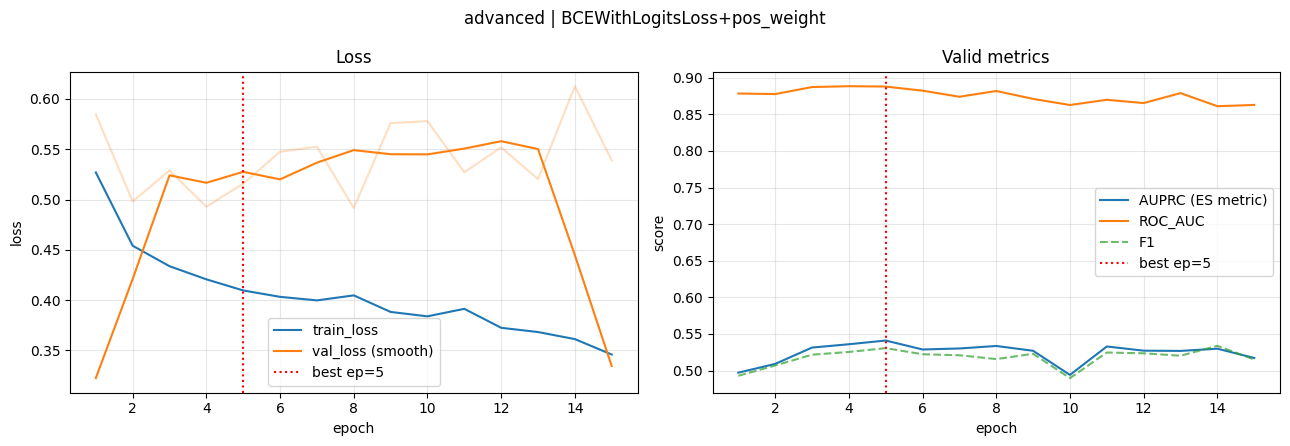

  ✓ weights → best_mlp_advanced_BCEWithLogitsLoss_pos_weight.pth
  ✓ history → history_advanced_BCEWithLogitsLoss_pos_weight.json
  VAL  : {'F1': 0.5306331709817995, 'Precision': 0.6486994672516453, 'Recall': 0.44892648015614833, 'ROC_AUC': 0.8880116029080106, 'AUPRC': 0.5410537763717399}
  TEST : {'F1': 0.4421315570358035, 'Precision': 0.5070019096117123, 'Recall': 0.39197834645669294, 'ROC_AUC': 0.8565033380368181, 'AUPRC': 0.4157750383613668} (thr=0.5518)

========== ADVANCED | FocalLoss(alpha=0.75,gamma=2.0) | dropout=0.15 ==========
  ep001 | tr_loss=0.0167 val_loss=0.0204 F1=0.4887 AUPRC=0.4973 ROC_AUC=0.8788 thr=0.314 lr=1.00e-03 | best_AUPRC=0.4973 (ep1)
  ep002 | tr_loss=0.0142 val_loss=0.0155 F1=0.5104 AUPRC=0.5175 ROC_AUC=0.8829 thr=0.498 lr=1.00e-03 | best_AUPRC=0.5175 (ep2)
  ep003 | tr_loss=0.0136 val_loss=0.0165 F1=0.5187 AUPRC=0.5274 ROC_AUC=0.8867 thr=0.401 lr=1.00e-03 | best_AUPRC=0.5274 (ep3)
  ep004 | tr_loss=0.0132 val_loss=0.0158 F1=0.5270 AUPRC=0.5353 ROC_AUC=0.8

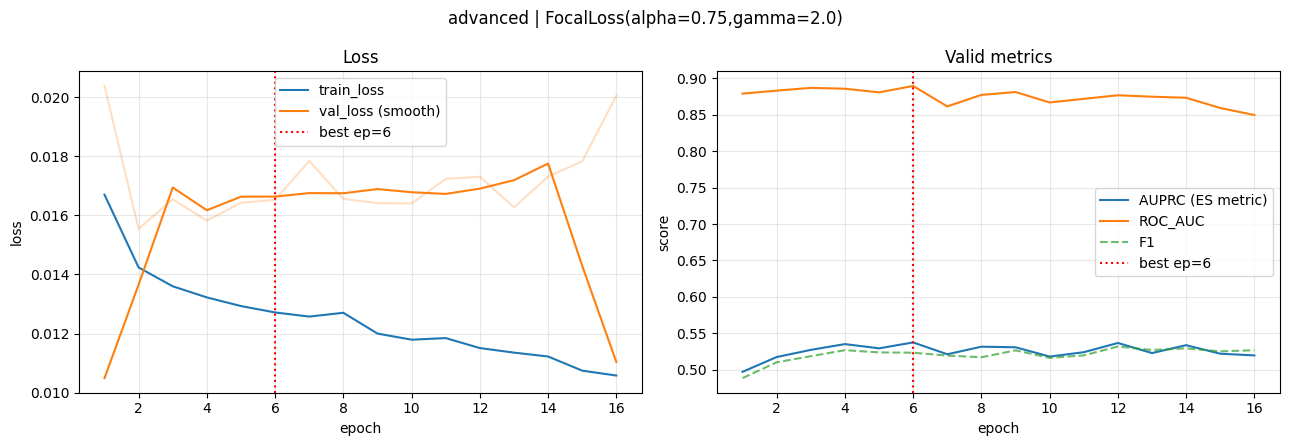

  ✓ weights → best_mlp_advanced_FocalLoss_alpha075_gamma20.pth
  ✓ history → history_advanced_FocalLoss_alpha075_gamma20.json
  VAL  : {'F1': 0.5234985273402484, 'Precision': 0.6391494684177611, 'Recall': 0.4432877900672305, 'ROC_AUC': 0.8893390880600692, 'AUPRC': 0.5375906960834388}
  TEST : {'F1': 0.44485555713675823, 'Precision': 0.5275059061761728, 'Recall': 0.38459645669291337, 'ROC_AUC': 0.8579985185214465, 'AUPRC': 0.39665307403651284} (thr=0.4300)

========== ADVANCED | DiceLoss | dropout=0.15 ==========
  ep001 | tr_loss=0.7841 val_loss=0.9615 F1=0.3681 AUPRC=0.3253 ROC_AUC=0.7462 thr=0.000 lr=1.00e-03 | best_AUPRC=0.3253 (ep1)
  ep002 | tr_loss=0.8853 val_loss=0.7345 F1=0.2701 AUPRC=0.1314 ROC_AUC=0.7235 thr=1.000 lr=1.00e-03 | best_AUPRC=0.3253 (ep1)
  ep003 | tr_loss=0.7433 val_loss=0.7368 F1=0.2907 AUPRC=0.1629 ROC_AUC=0.5909 thr=0.000 lr=1.00e-03 | best_AUPRC=0.3253 (ep1)
  ep004 | tr_loss=0.7882 val_loss=0.7721 F1=0.2281 AUPRC=0.1019 ROC_AUC=0.6633 thr=1.000 lr=1.00e-03 

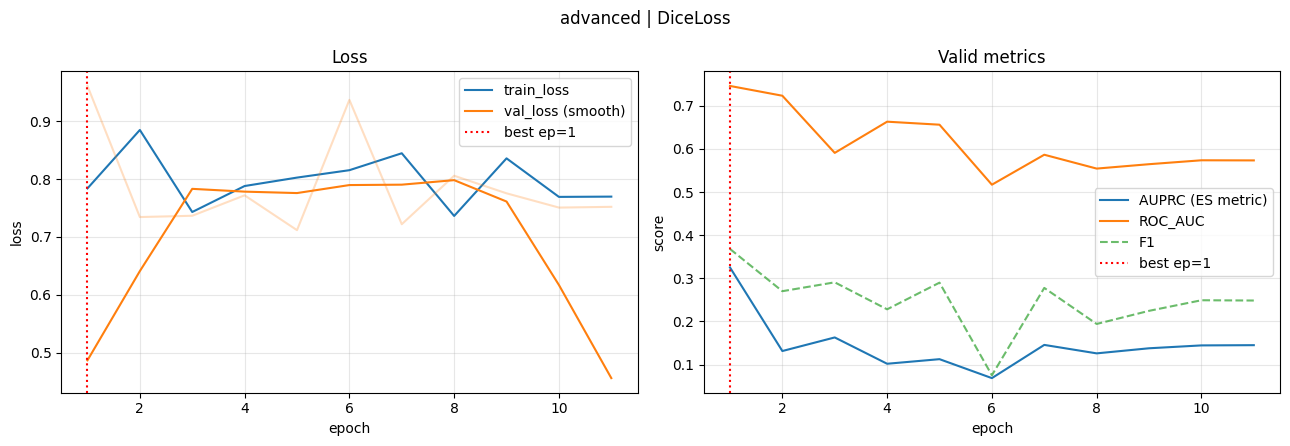

  ✓ weights → best_mlp_advanced_DiceLoss.pth
  ✓ history → history_advanced_DiceLoss.json
  VAL  : {'F1': 0.36814658210007045, 'Precision': 0.5257648953301127, 'Recall': 0.2832357406202559, 'ROC_AUC': 0.7461929480777164, 'AUPRC': 0.3252653120297071}
  TEST : {'F1': 0.2971898197242842, 'Precision': 0.3221264367816092, 'Recall': 0.27583661417322836, 'ROC_AUC': 0.739077256573095, 'AUPRC': 0.24916496071867877} (thr=0.0000)


,run_id,model,bottleneck,dropout,loss_fn,epochs_trained,val_loss,scoring_method,threshold_strategy,F1,Precision,Recall,ROC_AUC,AUPRC,threshold,notes,test_F1,test_AUC,test_AUPRC
0,14,FraudMLP_simple,-,0.15,BCEWithLogitsLoss+pos_weight,40,0.478264,sigmoid_prob,max_F1_on_valid,0.5312,0.6077,0.4719,0.8891,0.5442,0.7020,arch=simple | loss=BCEWithLogitsLoss+pos_weight | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=30 time=145s | test_F1=0.4462 test_AUC=0.8600 test_Gini=0.7200 test_AUPRC=0.3977,0.446156,0.859986,0.397720
1,15,FraudMLP_simple,-,0.15,"FocalLoss(alpha=0.75,gamma=2.0)",31,0.015119,sigmoid_prob,max_F1_on_valid,0.5299,0.5948,0.4778,0.8887,0.5439,0.4774,"arch=simple | loss=FocalLoss(alpha=0.75,gamma=2.0) | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=21 time=114s | test_F1=0.4410 test_AUC=0.8595 test_Gini=0.7189 test_AUPRC=0.3946",0.441041,0.859450,0.394623
6,20,FraudMLP_advanced,-,0.15,BCEWithLogitsLoss+pos_weight,15,0.515724,sigmoid_prob,max_F1_on_valid,0.5306,0.6487,0.4489,0.8880,0.5411,0.5518,arch=advanced | loss=BCEWithLogitsLoss+pos_weight | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=5 time=62s | test_F1=0.4421 test_AUC=0.8565 test_Gini=0.7130 test_AUPRC=0.4158,0.442132,0.856503,0.415775
7,21,FraudMLP_advanced,-,0.15,"FocalLoss(alpha=0.75,gamma=2.0)",16,0.016522,sigmoid_prob,max_F1_on_valid,0.5235,0.6391,0.4433,0.8893,0.5376,0.4300,"arch=advanced | loss=FocalLoss(alpha=0.75,gamma=2.0) | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=6 time=66s | test_F1=0.4449 test_AUC=0.8580 test_Gini=0.7160 test_AUPRC=0.3967",0.444856,0.857999,0.396653
3,17,FraudMLP_medium,-,0.15,BCEWithLogitsLoss+pos_weight,27,0.546700,sigmoid_prob,max_F1_on_valid,0.5238,0.6237,0.4515,0.8841,0.5343,0.5292,arch=medium | loss=BCEWithLogitsLoss+pos_weight | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=17 time=98s | test_F1=0.4483 test_AUC=0.8407 test_Gini=0.6814 test_AUPRC=0.4157,0.448334,0.840700,0.415658
4,18,FraudMLP_medium,-,0.15,"FocalLoss(alpha=0.75,gamma=2.0)",17,0.017465,sigmoid_prob,max_F1_on_valid,0.5247,0.6383,0.4455,0.8868,0.5320,0.3729,"arch=medium | loss=FocalLoss(alpha=0.75,gamma=2.0) | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=7 time=63s | test_F1=0.4430 test_AUC=0.8559 test_Gini=0.7117 test_AUPRC=0.4196",0.443020,0.855852,0.419570
2,16,FraudMLP_simple,-,0.15,DiceLoss,47,0.522053,sigmoid_prob,max_F1_on_valid,0.5015,0.6991,0.3910,0.8116,0.4453,0.0160,arch=simple | loss=DiceLoss | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=37 time=170s | test_F1=0.4537 test_AUC=0.7939 test_Gini=0.5877 test_AUPRC=0.3623,0.453681,0.793874,0.362278
5,19,FraudMLP_medium,-,0.15,DiceLoss,32,0.568040,sigmoid_prob,max_F1_on_valid,0.4754,0.7086,0.3576,0.8160,0.4097,0.0000,arch=medium | loss=DiceLoss | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=22 time=128s | test_F1=0.4322 test_AUC=0.8053 test_Gini=0.6107 test_AUPRC=0.3563,0.432177,0.805333,0.356316
8,22,FraudMLP_advanced,-,0.15,DiceLoss,11,0.961462,sigmoid_prob,max_F1_on_valid,0.3681,0.5258,0.2832,0.7462,0.3253,0.0000,arch=advanced | loss=DiceLoss | pos_w_used=10.00 | lr=0.001 wd=1e-5 bs=2048 patience=10 ES=AUPRC | best_ep=1 time=44s | test_F1=0.2972 test_AUC=0.7391 test_Gini=0.4782 test_AUPRC=0.2492,0.297190,0.739077,0.249165


In [10]:
summary = run_grid_search(
    X_train_proc, y_train, X_valid_proc, y_valid, X_test_proc, y_test,
    architectures=("simple", "medium", "advanced"),
    losses=("BCEWithLogitsLoss+pos_weight",
            "FocalLoss(alpha=0.75,gamma=2.0)",
            "DiceLoss"),
    max_epochs=80,
    patience=10,
    es_metric="AUPRC",     # albo "F1"
    pos_weight_cap=10.0,   # None = bez capa
    batch_size=2048,
)
summary.sort_values("AUPRC", ascending=False)

### Wnioski z eksperymentu:
* Funkcja straty DiceLoss nie radzi sobie za dobrze
* Funkcje BCE i Focal Loss bardzo podobnie sobie radziły
* Najlepiej na Test AUC i AUPRC wypadła kombinacja medium z Focal Loss
* Aktualnie modele były trenowane z lr = e-3, należy zmniejszyć learning rate
* Działaliśmy na stosunkowo dużym batch size, zmienimy to w dalszym tune modelu

### W dalszej analizie skupimy się na architekturze Medium + Focal loss, zmniejszymy learning rate


pos_weight raw=28.56, used=10.00 (cap=10.0); train_pos_rate=0.0338

========== MEDIUM | FocalLoss(alpha=0.75,gamma=2.0) | dropout=0.15 ==========
  ep001 | tr_loss=0.0161 val_loss=0.0166 F1=0.4781 AUPRC=0.4814 ROC_AUC=0.8667 thr=0.421 lr=5.00e-04 | best_AUPRC=0.4814 (ep1)
  ep002 | tr_loss=0.0145 val_loss=0.0163 F1=0.5102 AUPRC=0.5145 ROC_AUC=0.8789 thr=0.501 lr=5.00e-04 | best_AUPRC=0.5145 (ep2)
  ep003 | tr_loss=0.0140 val_loss=0.0157 F1=0.5115 AUPRC=0.5227 ROC_AUC=0.8844 thr=0.413 lr=5.00e-04 | best_AUPRC=0.5227 (ep3)
  ep004 | tr_loss=0.0137 val_loss=0.0152 F1=0.5203 AUPRC=0.5277 ROC_AUC=0.8879 thr=0.457 lr=5.00e-04 | best_AUPRC=0.5277 (ep4)
  ep005 | tr_loss=0.0134 val_loss=0.0157 F1=0.5120 AUPRC=0.5188 ROC_AUC=0.8837 thr=0.501 lr=5.00e-04 | best_AUPRC=0.5277 (ep4)
  ep006 | tr_loss=0.0132 val_loss=0.0159 F1=0.5181 AUPRC=0.5262 ROC_AUC=0.8832 thr=0.424 lr=5.00e-04 | best_AUPRC=0.5277 (ep4)
  ep007 | tr_loss=0.0131 val_loss=0.0162 F1=0.5248 AUPRC=0.5325 ROC_AUC=0.8837 thr=0.435 lr=

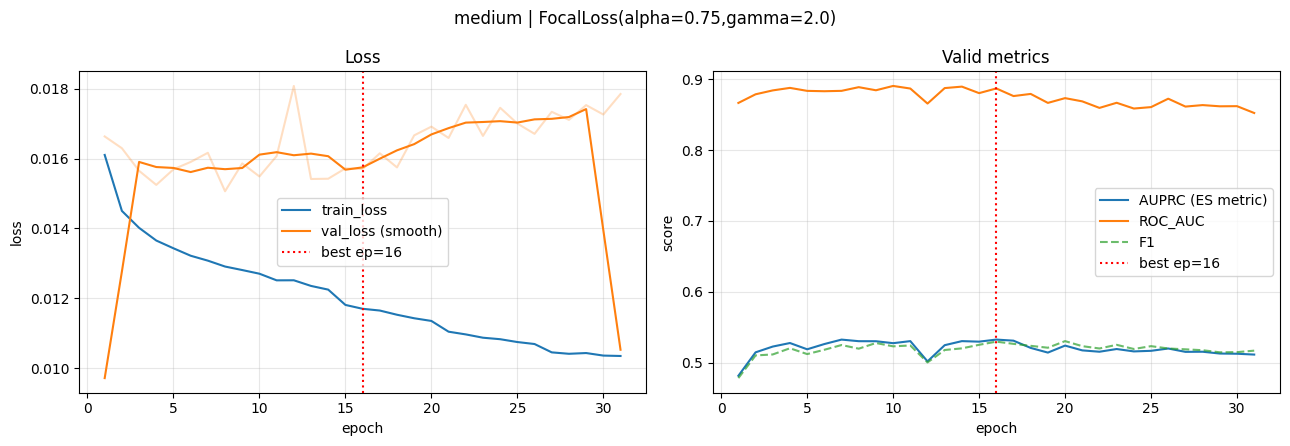

  ✓ weights → best_mlp_medium_FocalLoss_alpha075_gamma20_run10.pth
  ✓ history → history_medium_FocalLoss_alpha075_gamma20_run10.json
  VAL  : {'F1': 0.5296100144439095, 'Precision': 0.595077089532053, 'Recall': 0.4771199306007374, 'ROC_AUC': 0.8871317892265677, 'AUPRC': 0.5325230735759089}
  TEST : {'F1': 0.43479384774460383, 'Precision': 0.4579362918595154, 'Recall': 0.4138779527559055, 'ROC_AUC': 0.8416539120002585, 'AUPRC': 0.396318606621589} (thr=0.4459)
pos_weight raw=28.56, used=10.00 (cap=10.0); train_pos_rate=0.0338

========== MEDIUM | FocalLoss(alpha=0.75,gamma=2.0) | dropout=0.3 ==========
  ep001 | tr_loss=0.0169 val_loss=0.0167 F1=0.4756 AUPRC=0.4769 ROC_AUC=0.8709 thr=0.408 lr=5.00e-04 | best_AUPRC=0.4769 (ep1)
  ep002 | tr_loss=0.0151 val_loss=0.0160 F1=0.5051 AUPRC=0.5068 ROC_AUC=0.8782 thr=0.428 lr=5.00e-04 | best_AUPRC=0.5068 (ep2)
  ep003 | tr_loss=0.0145 val_loss=0.0160 F1=0.5126 AUPRC=0.5163 ROC_AUC=0.8821 thr=0.412 lr=5.00e-04 | best_AUPRC=0.5163 (ep3)
  ep004 | 

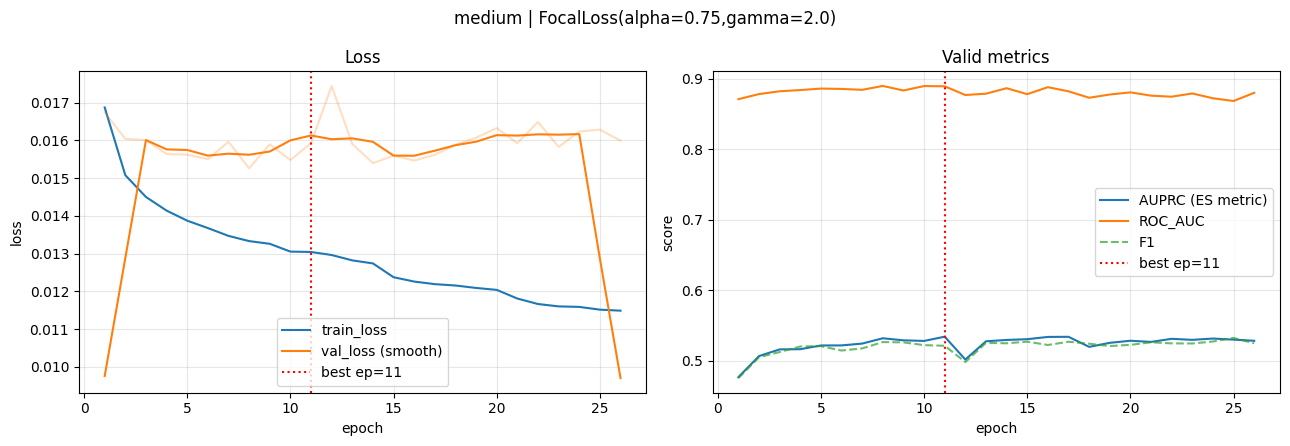

  ✓ weights → best_mlp_medium_FocalLoss_alpha075_gamma20_run11.pth
  ✓ history → history_medium_FocalLoss_alpha075_gamma20_run11.json
  VAL  : {'F1': 0.521399798590131, 'Precision': 0.6213621362136214, 'Recall': 0.44914335285187595, 'ROC_AUC': 0.8891855075597352, 'AUPRC': 0.534270456511618}
  TEST : {'F1': 0.45508486270180765, 'Precision': 0.5180647188187245, 'Recall': 0.40575787401574803, 'ROC_AUC': 0.8591438860401857, 'AUPRC': 0.4111309364686261} (thr=0.4315)
pos_weight raw=28.56, used=10.00 (cap=10.0); train_pos_rate=0.0338

========== MEDIUM | FocalLoss(alpha=0.75,gamma=2.0) | dropout=0.3 ==========
  ep001 | tr_loss=0.0167 val_loss=0.0166 F1=0.4763 AUPRC=0.4757 ROC_AUC=0.8712 thr=0.415 lr=1.00e-03 | best_AUPRC=0.4757 (ep1)
  ep002 | tr_loss=0.0150 val_loss=0.0161 F1=0.5111 AUPRC=0.5139 ROC_AUC=0.8810 thr=0.448 lr=1.00e-03 | best_AUPRC=0.5139 (ep2)
  ep003 | tr_loss=0.0144 val_loss=0.0157 F1=0.5166 AUPRC=0.5197 ROC_AUC=0.8830 thr=0.430 lr=1.00e-03 | best_AUPRC=0.5197 (ep3)
  ep004 

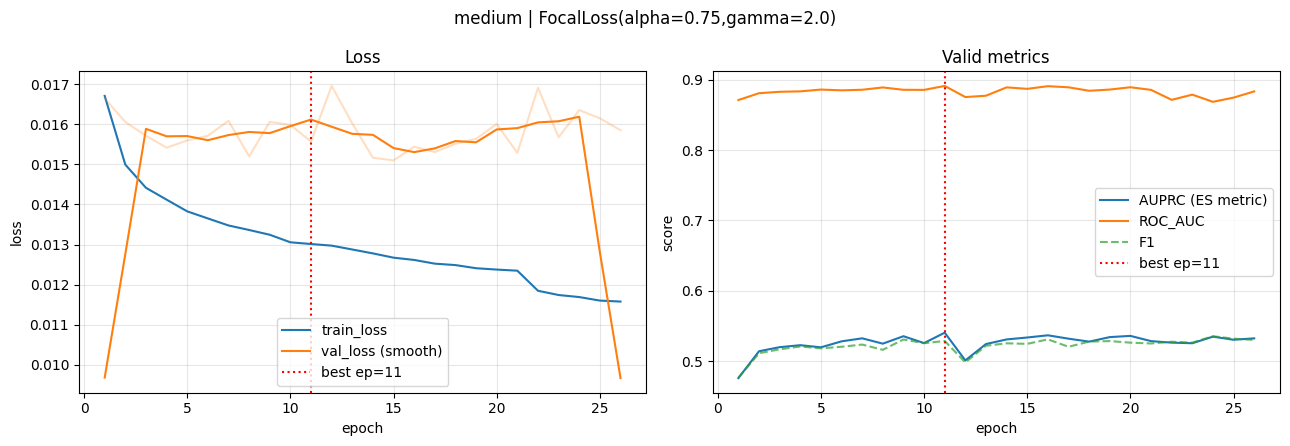

  ✓ weights → best_mlp_medium_FocalLoss_alpha075_gamma20_run12.pth
  ✓ history → history_medium_FocalLoss_alpha075_gamma20_run12.json
  VAL  : {'F1': 0.5285623003194888, 'Precision': 0.6434349719975109, 'Recall': 0.44849273476469315, 'ROC_AUC': 0.8913060855951283, 'AUPRC': 0.5403103068287689}
  TEST : {'F1': 0.44830972085846543, 'Precision': 0.5213703099510604, 'Recall': 0.39320866141732286, 'ROC_AUC': 0.8626313247190545, 'AUPRC': 0.41979508530324783} (thr=0.4741)


In [13]:
# ── Run 10: lr=5e-4, dropout=0.30 ────────────────────────────────────────────
summary_10 = run_grid_search(
X_train_proc, y_train, X_valid_proc, y_valid, X_test_proc, y_test,
architectures=("medium",),
losses=("FocalLoss(alpha=0.75,gamma=2.0)",),
max_epochs=100, patience=15, es_metric="AUPRC", pos_weight_cap=10.0,
lr=5e-4, batch_size=512,
dropout=0.15, tag_suffix="_run10",
)

# ── Run 11: lr=5e-4, dropout=0.30 ────────────────────────────────────────────
summary_11 = run_grid_search(
X_train_proc, y_train, X_valid_proc, y_valid, X_test_proc, y_test,
architectures=("medium",),
losses=("FocalLoss(alpha=0.75,gamma=2.0)",),
max_epochs=100, patience=15, es_metric="AUPRC", pos_weight_cap=10.0,
lr=5e-4, batch_size=512,
dropout=0.30, tag_suffix="_run11",
)

# ── Run 12: lr=1e-3, dropout=0.30 (finalny) ──────────────────────────────────
summary_12 = run_grid_search(
X_train_proc, y_train, X_valid_proc, y_valid, X_test_proc, y_test,
architectures=("medium",),
losses=("FocalLoss(alpha=0.75,gamma=2.0)",),
max_epochs=100, patience=15, es_metric="AUPRC", pos_weight_cap=10.0,
lr=1e-3, batch_size=512,
dropout=0.30, tag_suffix="_run12",
)

## Kody generujące tabele i wykresy do raportu

Próg decyzyjny (max F1 na valid) : 0.4741
Metryki testowe : {'F1': 0.44830972085846543, 'Precision': 0.5213703099510604, 'Recall': 0.39320866141732286, 'ROC_AUC': 0.8626313247190545, 'AUPRC': 0.41979508530324783}


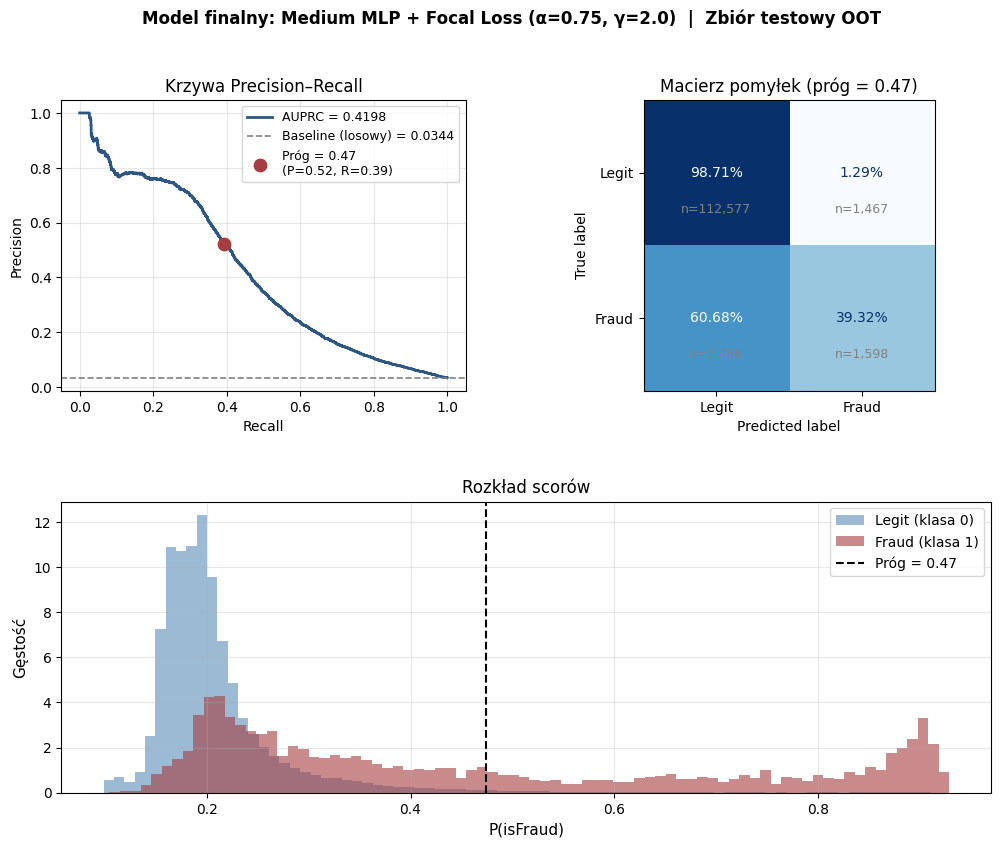


Zapisano: artifacts_mlp\plots\final_model_evaluation.png

─────────────────────────────────────────────
  TPR / Recall     : 39.32%  │  FNR (przeoczone fraudy) : 60.68%
  TNR              : 98.71%  │  FPR (fałszywy alarm)    : 1.29%
  Precision        : 52.14%
─────────────────────────────────────────────


In [15]:
# ── Wykresy ewaluacyjne modelu finalnego (Run 12: Medium + Focal Loss) ────────
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score,
)
from matplotlib.gridspec import GridSpec

# ── 1. Wczytanie modelu finalnego z pliku ─────────────────────────────────────
# Run 12: lr=1e-3, bs=512, dropout=0.30, patience=15
# Ostrożnie: `model` w pamięci = Run 10 (lr=5e-4) z poprzedniej komórki
FINAL_WEIGHTS = ART_DIR / "best_mlp_medium_FocalLoss_alpha075_gamma20_run12.pth"

final_model = MediumMLP(in_dim=X_test_proc.shape[1], dropout=0.30).to(DEVICE)
final_model.load_state_dict(torch.load(FINAL_WEIGHTS, map_location=DEVICE))
final_model.eval()

# ── 2. Predykcje i próg decyzyjny ─────────────────────────────────────────────
val_proba_f  = predict_proba(final_model, X_valid_proc)
test_proba_f = predict_proba(final_model, X_test_proc)

# Próg wyznaczony na zbiorze walidacyjnym (max F1)
thr_f, _ = best_f1_threshold(y_valid.values, val_proba_f)

y_test_arr  = y_test.values
y_pred_test = (test_proba_f >= thr_f).astype(int)

print(f"Próg decyzyjny (max F1 na valid) : {thr_f:.4f}")
print("Metryki testowe :", evaluate(y_test_arr, test_proba_f, thr_f))

# ── 3. Figura: PR + CM na górze, rozkład scorów na dole ──────────────────────
fig = plt.figure(figsize=(12, 9))
fig.suptitle(
    "Model finalny: Medium MLP + Focal Loss (α=0.75, γ=2.0)  |  Zbiór testowy OOT",
    fontsize=12, fontweight="bold",
)

gs = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)
ax_pr = fig.add_subplot(gs[0, 0])   # góra lewo  – Precision–Recall
ax_cm = fig.add_subplot(gs[0, 1])   # góra prawo – Macierz pomyłek
ax_sc = fig.add_subplot(gs[1, :])   # dół całość – Rozkład scorów

# ─────────────────────────────────────────────────────────────────────────────
# 3a. Krzywa Precision–Recall
# ─────────────────────────────────────────────────────────────────────────────
prec_c, rec_c, _ = precision_recall_curve(y_test_arr, test_proba_f)
auprc            = average_precision_score(y_test_arr, test_proba_f)
op_prec          = precision_score(y_test_arr, y_pred_test, zero_division=0)
op_rec           = recall_score(y_test_arr, y_pred_test, zero_division=0)

ax_pr.plot(rec_c, prec_c, color="#2C5784", lw=2, label=f"AUPRC = {auprc:.4f}")
ax_pr.axhline(
    y_test_arr.mean(), color="gray", linestyle="--", lw=1.2,
    label=f"Baseline (losowy) = {y_test_arr.mean():.4f}",
)
ax_pr.scatter(
    op_rec, op_prec, color="#A63D40", s=80, zorder=5,
    label=f"Próg = {thr_f:.2f}\n(P={op_prec:.2f}, R={op_rec:.2f})",
)
ax_pr.set_xlabel("Recall")
ax_pr.set_ylabel("Precision")
ax_pr.set_title("Krzywa Precision–Recall")
ax_pr.legend(fontsize=9)
ax_pr.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# 3b. Macierz pomyłek
# ─────────────────────────────────────────────────────────────────────────────
cm_raw  = confusion_matrix(y_test_arr, y_pred_test)
cm_norm = confusion_matrix(y_test_arr, y_pred_test, normalize="true")
tn, fp, fn, tp = cm_raw.ravel()

disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Legit", "Fraud"])
disp.plot(ax=ax_cm, cmap="Blues", values_format=".2%", colorbar=False)

for (i, j), val in np.ndenumerate(cm_raw):
    ax_cm.text(j, i + 0.25, f"n={val:,}", ha="center", va="center",
               fontsize=9, color="gray")

ax_cm.set_title(f"Macierz pomyłek (próg = {thr_f:.2f})")

# ─────────────────────────────────────────────────────────────────────────────
# 3c. Rozkład scorów
# ─────────────────────────────────────────────────────────────────────────────
ax_sc.hist(
    test_proba_f[y_test_arr == 0], bins=80, density=True,
    alpha=0.6, color="#5B8DB8", label="Legit (klasa 0)",
)
ax_sc.hist(
    test_proba_f[y_test_arr == 1], bins=80, density=True,
    alpha=0.6, color="#A63D40", label="Fraud (klasa 1)",
)
ax_sc.axvline(
    thr_f, color="black", linestyle="--", lw=1.5,
    label=f"Próg = {thr_f:.2f}",
)
ax_sc.set_xlabel("P(isFraud)", fontsize=11)
ax_sc.set_ylabel("Gęstość", fontsize=11)
ax_sc.set_title("Rozkład scorów")
ax_sc.legend(fontsize=10)
ax_sc.grid(alpha=0.3)

# ── 4. Zapis ─────────────────────────────────────────────────────────────────
save_path = PLOT_DIR / "final_model_evaluation.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nZapisano: {save_path}")

# ── 5. Podsumowanie macierzy pomyłek ─────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"  TPR / Recall     : {tp/(tp+fn):.2%}  │  FNR (przeoczone fraudy) : {fn/(tp+fn):.2%}")
print(f"  TNR              : {tn/(tn+fp):.2%}  │  FPR (fałszywy alarm)    : {fp/(tn+fp):.2%}")
print(f"  Precision        : {tp/(tp+fp):.2%}")
print(f"{'─'*45}")

## Tabela ewaluacyjna modeli z zapisanych wag (Train/Val/Test AUPRC + AUC)

In [17]:
EVAL_XLSX = Path("wyniki_eksperymentów.xlsx")


def _tag_safe(arch: str, loss_name: str) -> str:
    """Ta sama sanityzacja nazw co w run_grid_search."""
    tag = f"{arch}_{loss_name}".replace(" ", "").replace("/", "")
    return (tag
            .replace("+", "_")
            .replace("(", "_").replace(")", "")
            .replace("=", "").replace(",", "_").replace(".", ""))


def _auprc_auc(model: nn.Module, X: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    proba = predict_proba(model, X)   # robi model.eval() + sigmoid pod spodem
    return average_precision_score(y, proba), roc_auc_score(y, proba)


def build_eval_table(
    X_train_proc, y_train, X_valid_proc, y_valid, X_test_proc, y_test,
    specs: list[tuple[str, str, str]] | None = None,
    architectures=("simple", "medium", "advanced"),
    losses=("BCEWithLogitsLoss+pos_weight",
            "FocalLoss(alpha=0.75,gamma=2.0)",
            "DiceLoss"),
    tag_suffix: str = "",
    art_dir: Path = ART_DIR,
    hist_dir: Path = HIST_DIR,
    save_path: Path = EVAL_XLSX,
    es_metric: str = "AUPRC",
) -> pd.DataFrame:
    """Tabela ewaluacyjna z zapisanych wag, z DWIEMA deltami.

      specs : opcjonalna lista krotek (arch, loss_name, nazwa_pliku_wag). Przy None:
              iteruje po (architectures × losses) + tag_suffix i bierze pliki, które
              istnieją na dysku.

    delta (Train-Val) = przeuczenie; delta (Val-Test) = spadek na OOT.
    Dropout nieistotny przy ewaluacji (model.eval() go wyłącza).
    """
    in_dim = X_train_proc.shape[1]
    ytr = np.asarray(y_train); yva = np.asarray(y_valid); yte = np.asarray(y_test)

    if specs is None:
        specs = [(a, l, f"best_mlp_{_tag_safe(a, l)}{tag_suffix}.pth")
                 for a in architectures for l in losses]

    rows = []
    for arch, loss_name, wfname in specs:
        wpath = art_dir / wfname
        if not wpath.exists():
            print(f"  ⚠ pomijam (brak wag): {wfname}")
            continue

        model = build_model(arch, in_dim).to(DEVICE)   # dropout nieistotny w eval
        model.load_state_dict(torch.load(wpath, map_location=DEVICE))
        model.eval()

        tr_ap, tr_auc = _auprc_auc(model, X_train_proc, ytr)
        va_ap, va_auc = _auprc_auc(model, X_valid_proc, yva)
        te_ap, te_auc = _auprc_auc(model, X_test_proc, yte)

        # Najlepsza epoka: argmax val_AUPRC z odpowiadającej historii.
        hist_name = "history_" + wfname[len("best_mlp_"):].replace(".pth", ".json")
        hpath = hist_dir / hist_name
        best_ep = None
        if hpath.exists():
            with open(hpath, encoding="utf-8") as f:
                hist = json.load(f)
            key = f"val_{es_metric}"
            if hist.get(key):
                k = int(np.argmax(hist[key]))
                best_ep = hist["epoch"][k]
        else:
            print(f"  ⚠ brak historii ({hist_name}) → 'Najlepsza epoka' = NaN dla {arch}/{loss_name}")

        rows.append({
            "Architektura":            arch,
            "Fn straty":               loss_name,
            "Train AUPRC":             round(tr_ap, 4),
            "Train AUC":               round(tr_auc, 4),
            "Val AUPRC":               round(va_ap, 4),
            "Val AUC":                 round(va_auc, 4),
            "Test AUPRC":              round(te_ap, 4),
            "Test AUC":                round(te_auc, 4),
            "Najlepsza epoka":         best_ep,
            "delta AUPRC (Train-Val)": round(tr_ap - va_ap, 4),   # przeuczenie
            "delta AUC (Train-Val)":   round(tr_auc - va_auc, 4),  # przeuczenie
            "delta AUPRC (Val-Test)":  round(va_ap - te_ap, 4),   # generalizacja OOT
            "delta AUC (Val-Test)":    round(va_auc - te_auc, 4),  # generalizacja OOT
        })
        print(f"  ✓ {arch:9s} | {loss_name:35s} | "
              f"Test AUPRC={te_ap:.4f} AUC={te_auc:.4f} | best_ep={best_ep}")

    df = pd.DataFrame(rows, columns=[
        "Architektura", "Fn straty", "Train AUPRC", "Train AUC",
        "Val AUPRC", "Val AUC", "Test AUPRC", "Test AUC", "Najlepsza epoka",
        "delta AUPRC (Train-Val)", "delta AUC (Train-Val)",
        "delta AUPRC (Val-Test)", "delta AUC (Val-Test)",
    ])
    df.to_excel(save_path, index=False)
    print(f"\n✓ Zapisano tabelę ewaluacyjną → {save_path}  ({len(df)} modeli)")
    return df

In [18]:
# Tabela ewaluacyjna dla wszystkich modeli z grid searchu (9 plików wag).
# Czyta wagi z artifacts_mlp/, liczy AUPRC + ROC AUC na train/val/test,
# najlepszą epokę z historii i zapisuje do wyniki_eksperymentów.xlsx.
specs = [
    # ── 9 modeli z grid searchu (selekcja architektury) ──
    ("simple",   "BCEWithLogitsLoss+pos_weight",    "best_mlp_simple_BCEWithLogitsLoss_pos_weight.pth"),
    ("simple",   "FocalLoss(alpha=0.75,gamma=2.0)", "best_mlp_simple_FocalLoss_alpha075_gamma20.pth"),
    ("simple",   "DiceLoss",                        "best_mlp_simple_DiceLoss.pth"),
    ("medium",   "BCEWithLogitsLoss+pos_weight",    "best_mlp_medium_BCEWithLogitsLoss_pos_weight.pth"),
    ("medium",   "FocalLoss(alpha=0.75,gamma=2.0)", "best_mlp_medium_FocalLoss_alpha075_gamma20.pth"),
    ("medium",   "DiceLoss",                        "best_mlp_medium_DiceLoss.pth"),
    ("advanced", "BCEWithLogitsLoss+pos_weight",    "best_mlp_advanced_BCEWithLogitsLoss_pos_weight.pth"),
    ("advanced", "FocalLoss(alpha=0.75,gamma=2.0)", "best_mlp_advanced_FocalLoss_alpha075_gamma20.pth"),
    ("advanced", "DiceLoss",                        "best_mlp_advanced_DiceLoss.pth"),
    # ── 3 modele z tuningu (medium + Focal), rozróżnione etykietą ──
    ("medium", "Focal — Run 10 (lr=5e-4, bs=512, do=0.15)", "best_mlp_medium_FocalLoss_alpha075_gamma20_run10.pth"),
    ("medium", "Focal — Run 11 (lr=5e-4, bs=512, do=0.30)", "best_mlp_medium_FocalLoss_alpha075_gamma20_run11.pth"),
    ("medium", "Focal — Run 12 (lr=1e-3, bs=512, do=0.30)", "best_mlp_medium_FocalLoss_alpha075_gamma20_run12.pth"),
]

df_eval = build_eval_table(
    X_train_proc, y_train, X_valid_proc, y_valid, X_test_proc, y_test,
    specs=specs,
    save_path=Path("wyniki_eksperymentów.xlsx"),
)
df_eval

  ✓ simple    | BCEWithLogitsLoss+pos_weight        | Test AUPRC=0.3977 AUC=0.8600 | best_ep=30
  ✓ simple    | FocalLoss(alpha=0.75,gamma=2.0)     | Test AUPRC=0.3946 AUC=0.8595 | best_ep=21
  ✓ simple    | DiceLoss                            | Test AUPRC=0.3623 AUC=0.7939 | best_ep=37
  ✓ medium    | BCEWithLogitsLoss+pos_weight        | Test AUPRC=0.4157 AUC=0.8407 | best_ep=17
  ✓ medium    | FocalLoss(alpha=0.75,gamma=2.0)     | Test AUPRC=0.4196 AUC=0.8559 | best_ep=7
  ✓ medium    | DiceLoss                            | Test AUPRC=0.3563 AUC=0.8053 | best_ep=22
  ✓ advanced  | BCEWithLogitsLoss+pos_weight        | Test AUPRC=0.4158 AUC=0.8565 | best_ep=5
  ✓ advanced  | FocalLoss(alpha=0.75,gamma=2.0)     | Test AUPRC=0.3967 AUC=0.8580 | best_ep=6
  ✓ advanced  | DiceLoss                            | Test AUPRC=0.2492 AUC=0.7391 | best_ep=1
  ✓ medium    | Focal — Run 10 (lr=5e-4, bs=512, do=0.15) | Test AUPRC=0.3963 AUC=0.8417 | best_ep=16
  ✓ medium    | Focal — Run 11 (lr=5e-

,Architektura,Fn straty,Train AUPRC,Train AUC,Val AUPRC,Val AUC,Test AUPRC,Test AUC,Najlepsza epoka,delta AUPRC (Train-Val),delta AUC (Train-Val),delta AUPRC (Val-Test),delta AUC (Val-Test)
0,simple,BCEWithLogitsLoss+pos_weight,0.6237,0.9171,0.5442,0.8891,0.3977,0.8600,30,0.0795,0.0279,0.1464,0.0292
1,simple,"FocalLoss(alpha=0.75,gamma=2.0)",0.6130,0.9098,0.5439,0.8887,0.3946,0.8595,21,0.0691,0.0211,0.1493,0.0293
2,simple,DiceLoss,0.4644,0.7776,0.4453,0.8116,0.3623,0.7939,37,0.0191,-0.0340,0.0830,0.0177
3,medium,BCEWithLogitsLoss+pos_weight,0.6287,0.9166,0.5343,0.8841,0.4157,0.8407,17,0.0943,0.0324,0.1187,0.0434
4,medium,"FocalLoss(alpha=0.75,gamma=2.0)",0.5938,0.9035,0.5320,0.8868,0.4196,0.8559,7,0.0618,0.0167,0.1124,0.0309
5,medium,DiceLoss,0.4005,0.7812,0.4097,0.8160,0.3563,0.8053,22,-0.0092,-0.0348,0.0534,0.0107
6,advanced,BCEWithLogitsLoss+pos_weight,0.6055,0.9058,0.5411,0.8880,0.4158,0.8565,5,0.0645,0.0178,0.1253,0.0315
7,advanced,"FocalLoss(alpha=0.75,gamma=2.0)",0.6199,0.9070,0.5376,0.8893,0.3967,0.8580,6,0.0823,0.0177,0.1409,0.0313
8,advanced,DiceLoss,0.2476,0.7265,0.3253,0.7462,0.2492,0.7391,1,-0.0777,-0.0197,0.0761,0.0071
9,medium,"Focal — Run 10 (lr=5e-4, bs=512, do=0.15)",0.6625,0.9225,0.5325,0.8871,0.3963,0.8417,16,0.1300,0.0354,0.1362,0.0455
